# Unsupervised Learning: Clustering Lab





In [ ]:
import pandas as pd
from scipy.io import arff
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score

## 1. Initial practice with the K-means and HAC algorithms

### 1.1 K-means
Run K-means on this [Abalone Dataset.](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/abalone.arff)
The dataset was modified to be smaller. The last datapoint should be on line 359 or the point 0.585,0.46,0.185,0.922,0.3635,0.213,0.285,10. The remaining points are commented out. Treat the output class (last column) as an additional input feature. Create your K-Mmeans model with the paramaters K-means(n_clusters=3, init='random', n_init=1)

Output the following:
- Class label for each point (labels_)
- The k=3 cluster centers (cluster_centers_)
- Number of iterations it took to converge (n_iter_)
- Total sum squared error of each point from its cluster center (inertia_)
- The total average silhouette score (see sklearn.metrics silhouette_score)

In [ ]:
# K-means with Abalone
import io

import requests

data_url = (
    "https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/abalone.arff"
)
response = requests.get(data_url)

# Load the ARFF data from the downloaded content after decoding it to a string
data = arff.loadarff(io.StringIO(response.content.decode("utf-8")))

df_abalone = pd.DataFrame(data[0])

# Decode byte strings in the DataFrame
for column in df_abalone.select_dtypes(include=["object"]).columns:
    df_abalone[column] = df_abalone[column].str.decode("utf-8")

df_abalone.head()
# df_abalone.info()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15.0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7.0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9.0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10.0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7.0


In [ ]:
X_abalone = df_abalone.copy()

# Create K-Means model
kmeans = KMeans(
    n_clusters=3, init="random", n_init=1, random_state=42
)  # Added random_state for reproducibility

# Fit the model to the data
kmeans.fit(X_abalone)

print(f"Class label for each point (labels_):\n{kmeans.labels_}")
print(f"\nThe k=3 cluster centers (cluster_centers_):\n{kmeans.cluster_centers_}")
print(f"\nNumber of iterations it took to converge (n_iter_): {kmeans.n_iter_}")
print(
    f"\nTotal sum squared error of each point from its cluster center (inertia_): {kmeans.inertia_}"
)

# Calculate and print the total average silhouette score
sil_score_abalone = silhouette_score(X_abalone, kmeans.labels_)
print(f"\nTotal average silhouette score: {sil_score_abalone}")

Class label for each point (labels_):
[1 2 2 2 2 2 1 1 2 1 0 2 0 2 2 0 2 2 2 2 0 2 0 2 2 0 0 0 1 0 2 1 1 1 0 2 1
 2 0 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 2 2 0 2 1 0
 0 1 2 2 0 0 2 0 1 1 0 0 0 2 2 0 1 0 0 2 1 0 2 2 2 2 2 1 1 2 0 0 0 2 2 2 2
 2 2 2 0 0 0 2 2 2 2 2 0 2 2 2 2 2 1 1 1 2 2 2 2 2 2 2 2 2 2 2 1 0 2 2 2 2
 2 2 1 2 2 2 0 2 0 1 0 0 0 0 0 1 1 0 1 1 0 0 0 2 2 2 2 2 2 2 2 0 0 1 2 2 0
 0 0 2 0 2 0 0 0 2 2 0 0 1 1 2]

The k=3 cluster centers (cluster_centers_):
[[ 0.58122807  0.45649123  0.1604386   1.05523684  0.41045614  0.231
   0.33986842 12.33333333]
 [ 0.61366667  0.48933333  0.16716667  1.29283333  0.48815     0.25873333
   0.45488333 17.06666667]
 [ 0.44221239  0.3439823   0.11331858  0.49762832  0.20678319  0.11430973
   0.15534513  8.24778761]]

Number of iterations it took to converge (n_iter_): 5

Total sum squared error of each point from its cluster center (inertia_): 540.2109608826969

Total average silhouette score: 0.5010728634549578


#### Discussion
Discuss your results. Run it a few times. What happens? How did the cluster silhouette scores compare? <br>
Now play around with k. What happens to the clusters and silhouette scores?

The clusters seem reasonable, but the silhouette scores suggest that better groupings may be possible. Across the tested k values, adding more clusters required more iterations but did not consistently improve the silhouette score; it went up and down as k changed.

### 1.2 Hierarchical Agglomerative Clustering (HAC)

Run HAC on the same [Abalone Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/abalone.arff) using complete linkage and k=3.

Output the following:
- Class label for each point (labels_)
- The total average silhouette score

In [ ]:
# HAC with Abalone

# HAC with complete linkage and k=3
hac = AgglomerativeClustering(n_clusters=3, linkage="complete")

# Fit the model to the data and get labels
hac_labels = hac.fit_predict(X_abalone)

print(f"Class label for each point (labels_):\n{hac_labels}")

# Calculate and print the total average silhouette score
sil_score_hac_abalone = silhouette_score(X_abalone, hac_labels)
print(f"\nTotal average silhouette score: {sil_score_hac_abalone}")

Class label for each point (labels_):
[1 0 0 0 0 0 2 1 0 2 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 2 2 1 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 2 1
 1 1 0 0 1 1 0 1 1 2 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 2 2 2 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 1 0 1 1 1 1 1 1 1 2 1 1 2 2 1 1 1 0 0 0 0 0 0 0 0 1 1 2 0 0 1
 1 1 0 1 0 1 1 1 0 0 1 0 1 1 0]

Total average silhouette score: 0.5398112398376158


#### Discussion
How do the clusters compare to your results above? Explain the differences using what you know about HAC.

The HAC labels look very different from the K-means labels, but cluster labels are arbitrary identifiers, so the label numbers themselves cannot be compared directly. The membership differences are consistent with the algorithms using different cluster-building strategies. With complete linkage, clusters are merged based on the farthest pair of points, rather than distance from a centroid.

## 2. K-means Clustering with the [Iris Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff)
Use the Iris data set for 2.1 and 2.2.  Don't include the output label as one of the input features.

### 2.1 K-means Initial Centroids Experiments
K-means results differ based on the initial centroids used.
- Run K-means 5 times with *k*=4, each time with different initial random centroids (init="random) and with n_init=1.  Give inertia and silhouette scores for each run and discuss any variations in the results.
- SKlearn has a parameter that does this automatically (n_init).  n_init = z runs K-means z times, each with different random centroids and returns the clustering with the best SSE (intertia) of the z runs. Try it out and discuss how it does and how it compares with your 5 runs above.
- Sklearn also has a parameter (init:'K-means++') which runs a simpler fast version of K-means first on the data to come up with good initial centroids, and then runs regular K-means with this centroids.  Try it out (with n_init = 1) and discuss.

In [ ]:
# K-means initial centroid experiments
import io

import pandas as pd
import requests
from scipy.io import arff

iris_data_url = (
    "https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff"
)
response = requests.get(iris_data_url)
data = arff.loadarff(io.StringIO(response.content.decode("utf-8")))
df_iris = pd.DataFrame(data[0])

for column in df_iris.select_dtypes(include=["object"]).columns:
    df_iris[column] = df_iris[column].str.decode("utf-8")

X_iris = df_iris.drop(columns=[df_iris.columns[-1]])

X_iris.head()

,sepallength,sepalwidth,petallength,petalwidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = 4

print(
    f"K-Means Clustering with k={k}, init='random', n_init=1 (5 runs with different random_state)\n"
)

for i in range(5):
    kmeans = KMeans(n_clusters=k, init="random", n_init=1, random_state=i)
    kmeans.fit(X_iris)
    silhouette_avg = silhouette_score(X_iris, kmeans.labels_)

    # Print results for the current run
    print(f"Run {i + 1}:")
    print(f"  Inertia (SSE): {kmeans.inertia_}")
    print(f"  Silhouette Score: {silhouette_avg}")
    print("\n")

K-Means Clustering with k=4, init='random', n_init=1 (5 runs with different random_state)

Run 1:
  Inertia (SSE): 57.371482025432464
  Silhouette Score: 0.49739559767537483


Run 2:
  Inertia (SSE): 71.34044682436698
  Silhouette Score: 0.4171050599264815


Run 3:
  Inertia (SSE): 57.34540931571815
  Silhouette Score: 0.4972279726640147


Run 4:
  Inertia (SSE): 57.34540931571815
  Silhouette Score: 0.4972279726640147


Run 5:
  Inertia (SSE): 57.4732732654949
  Silhouette Score: 0.49511999553021513




In [ ]:
k = 4

# K-means with n_init=auto (e.g., n_init=10 for older sklearn versions)
print(f"\nK-Means Clustering with k={k}, init='random', n_init='auto' (or 10 runs):")
kmeans_n_init_auto = KMeans(
    n_clusters=k, init="random", n_init=10, random_state=42
)  # Using 10 as per suggestion, fixed random_state for overall reproducibility
kmeans_n_init_auto.fit(X_iris)
silhouette_avg_n_init_auto = silhouette_score(X_iris, kmeans_n_init_auto.labels_)
print(f"  Inertia (SSE): {kmeans_n_init_auto.inertia_}")
print(f"  Silhouette Score: {silhouette_avg_n_init_auto}")

# K-means with init='k-means++' and n_init=1
print(f"\nK-Means Clustering with k={k}, init='k-means++', n_init=1:")
kmeans_k_means_plus_plus = KMeans(
    n_clusters=k, init="k-means++", n_init=1, random_state=42
)  # Fixed random_state for reproducibility
kmeans_k_means_plus_plus.fit(X_iris)
silhouette_avg_k_means_plus_plus = silhouette_score(
    X_iris, kmeans_k_means_plus_plus.labels_
)
print(f"  Inertia (SSE): {kmeans_k_means_plus_plus.inertia_}")
print(f"  Silhouette Score: {silhouette_avg_k_means_plus_plus}")


K-Means Clustering with k=4, init='random', n_init='auto' (or 10 runs):
  Inertia (SSE): 57.317873214285726
  Silhouette Score: 0.4978256901095472

K-Means Clustering with k=4, init='k-means++', n_init=1:
  Inertia (SSE): 57.44028021295475
  Silhouette Score: 0.4974115445023624


#### Discussion
Discuss your results. How does n_init work and compare with your first results without using n_init. <br>
How does K-means++ work? Compare it to your previous runs.

`n_init` performs the same type of repeated initialization as the manual experiments. Its inertia and silhouette scores were similar to the better manual runs, while K-means++ also performed similarly in this dataset. The built-in options make these comparisons easier to run than writing the loop manually.

### 2.2 (20%) Silhouette Graphs
In this part you will show silhouette graphs for different *k* values.  Install the [Yellowbrick visualization package](https://www.scikit-yb.org/en/latest/quickstart.html) and import the [Silhouette Visualizer](https://www.scikit-yb.org/en/latest/api/cluster/silhouette.html).  This library includes lots of visualization packages which you might find useful. (Note: The YellowBrick silhouette visualizer does not currently support HAC).
- Show Silhouette graphs for clusterings with *k* = 2-6. Print the SSE (inertia) and total silhouette score for each.
- Learn with the default n_init = 10 to help insure a decent clustering.
- Using the silhouette graphs, choose which *k* you think is best and discuss why. Think about and discuss more than just the total silhouette score.


Clustering with k = 2
  Inertia (SSE): 152.36870647733915
  Silhouette Score: 0.6808136202936816


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


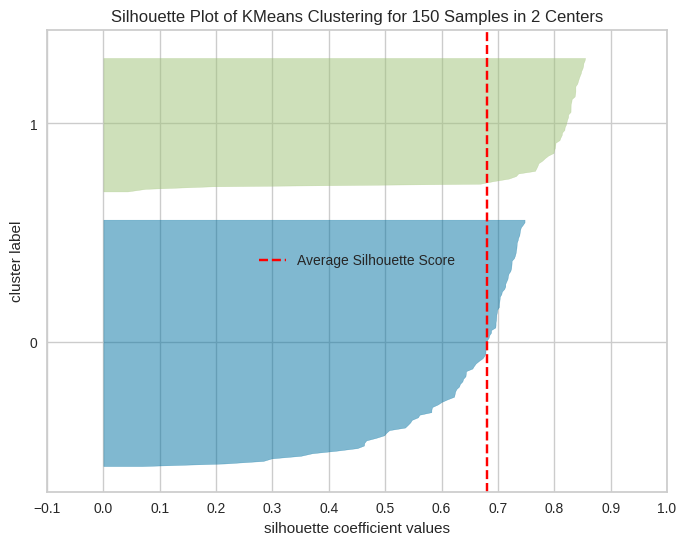


Clustering with k = 3
  Inertia (SSE): 78.94084142614601
  Silhouette Score: 0.5525919445499757


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


<Figure size 800x550 with 0 Axes>

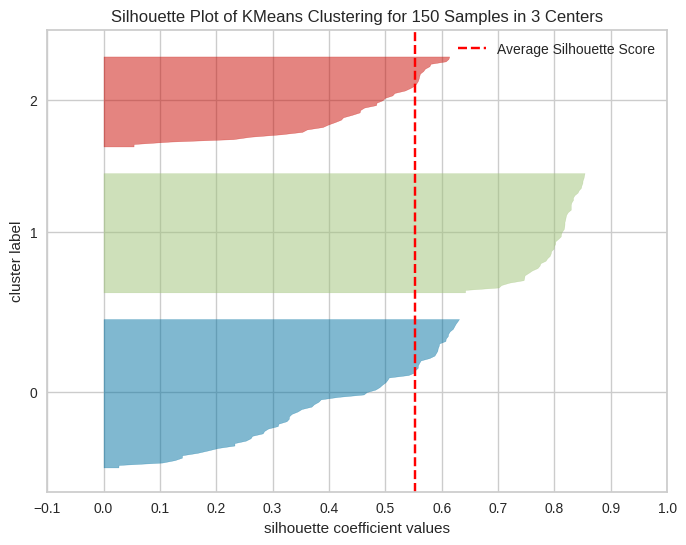


Clustering with k = 4
  Inertia (SSE): 57.317873214285726
  Silhouette Score: 0.4978256901095472


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


<Figure size 800x550 with 0 Axes>

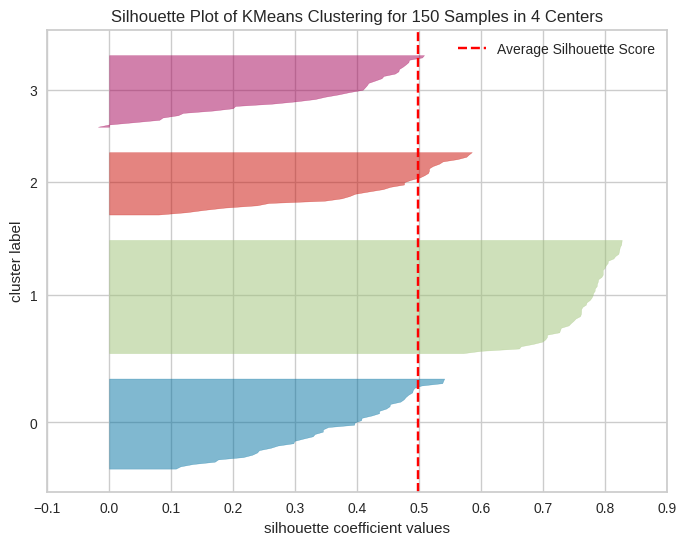


Clustering with k = 5
  Inertia (SSE): 46.535582051282034
  Silhouette Score: 0.4885175508886279


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


<Figure size 800x550 with 0 Axes>

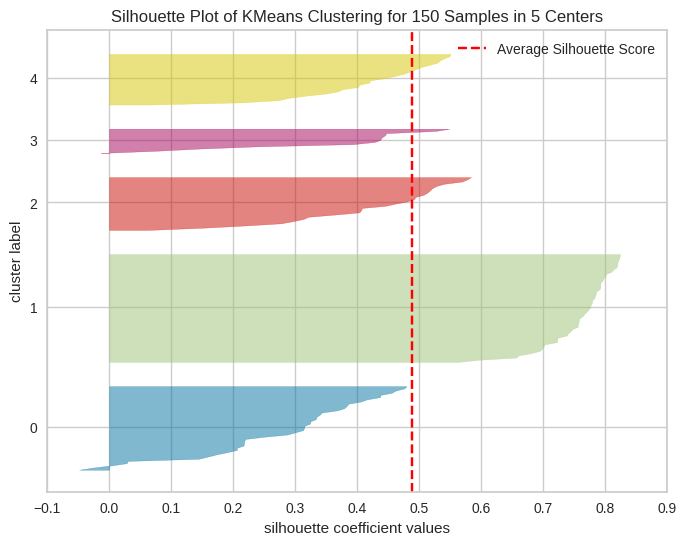


Clustering with k = 6
  Inertia (SSE): 38.930963049671746
  Silhouette Score: 0.36820569682713084


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


<Figure size 800x550 with 0 Axes>

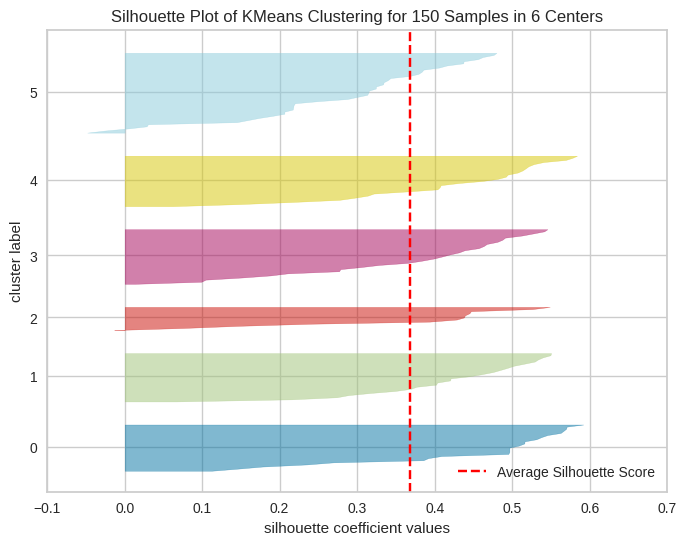

<Figure size 800x550 with 0 Axes>

In [ ]:
# Iris Clustering with K-means and silhouette graphs
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer

for k in range(2, 7):
    print(f"\nClustering with k = {k}")

    kmeans_model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)

    # Fit the KMeans model to the data
    kmeans_model.fit(X_iris)

    # Print inertia and silhouette score
    inertia = kmeans_model.inertia_
    silhouette_avg = silhouette_score(X_iris, kmeans_model.labels_)
    print(f"  Inertia (SSE): {inertia}")
    print(f"  Silhouette Score: {silhouette_avg}")

    # Create and display Silhouette Visualizer
    fig, ax = plt.subplots(figsize=(8, 6))
    visualizer = SilhouetteVisualizer(kmeans_model, colors="yellowbrick", ax=ax)
    visualizer.fit(X_iris)
    visualizer.show()
    plt.clf()  # Clear the current figure to prevent plots from stacking

#### Discussion
Discuss your results and justify which clustering is best based on the silhouette graphs

`k=2` appears to be the best option for this experiment. It had the highest silhouette score, about 0.681, and its silhouette plot was relatively uniform and well separated. The silhouette shapes became less favorable as k increased.

## 3 (20%) Iris Clustering with HAC

- Use the same dataset as above and learn with HAC clustering
- Create one table with silhouette scores for k=2-6 for each of the linkage options single, average, complete, and ward

In [ ]:
# HAC with Iris
hac_results = []

linkage_types = ["single", "average", "complete", "ward"]

for k in range(2, 7):
    for linkage in linkage_types:
        hac_model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        hac_labels = hac_model.fit_predict(X_iris)
        silhouette_avg = silhouette_score(X_iris, hac_labels)
        hac_results.append(
            {"k": k, "linkage": linkage, "silhouette_score": silhouette_avg}
        )

# See results as df
hac_results_df = pd.DataFrame(hac_results)
hac_results_df

,k,linkage,silhouette_score
0,2,single,0.686393
1,2,average,0.686393
2,2,complete,0.516060
3,2,ward,0.686393
4,3,single,0.511839
5,3,average,0.553934
6,3,complete,0.513350
7,3,ward,0.554097
8,4,single,0.281778
9,4,average,0.471665


#### Discussion
Discuss your results and compare with your k-means results. <br>
Discuss your table that contains the silhouette scores for k=2,3,4,5,6 and for each of the different linkage options. <br>
Discuss how the linkage options affect your scores.

The HAC results generally show lower silhouette scores as the number of clusters increases. The best linkage depends on k: at `k=2`, complete linkage is the weakest option, while at `k=6`, single linkage is the weakest and the other linkages are also lower.

Compared with the K-means results, HAC performs better at smaller k values and worse at larger k values in these experiments, based on the silhouette scores.

## 4 Run both algorithms on a real world data
- Choose any real world data set which you have not used previously
- Use parameters of your choosing
- Try each algorithm a few times with different parameters and output one typical example of labels and silhouette scores for each algorithm
- Show the silhouette graph for at least one reasonable *k* value for K-means

In [ ]:
# Run both algoriths on a data set of your choice

wine_quality_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df_wine = pd.read_csv(wine_quality_url, sep=";")
df_wine.drop(df_wine.columns[-1], axis=1, inplace=True)

df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_wine_scaled = pd.DataFrame(scaler.fit_transform(df_wine), columns=df_wine.columns)

X_wine_scaled.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246


In [ ]:
k = 3  # Chosen k for K-means clustering

kmeans_model_wine = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)

kmeans_model_wine.fit(X_wine_scaled)

print(f"K-Means Clustering with k={k}:")
print(f"  Class labels for each point (labels_):\n{kmeans_model_wine.labels_}")
print(f"  Cluster centers (cluster_centers_):\n{kmeans_model_wine.cluster_centers_}")
print(f"  Number of iterations (n_iter_): {kmeans_model_wine.n_iter_}")
print(f"  Inertia (SSE): {kmeans_model_wine.inertia_}")

silhouette_avg_wine = silhouette_score(X_wine_scaled, kmeans_model_wine.labels_)
print(f"  Silhouette Score: {silhouette_avg_wine}")

K-Means Clustering with k=3:
  Class labels for each point (labels_):
[0 2 0 ... 0 0 0]
  Cluster centers (cluster_centers_):
[[-0.64907467  0.45541847 -0.75961978 -0.23040106 -0.18945376 -0.22638711
  -0.35192467 -0.45067488  0.61325445 -0.28871833  0.0667032 ]
 [ 1.00398862 -0.68568878  1.02077194  0.03104975  0.27616274 -0.47686049
  -0.48168723  0.43844069 -0.75207155  0.55462042  0.28259117]
 [-0.09432101  0.04107636  0.09604791  0.40203359 -0.00492821  1.07422789
   1.32239093  0.28077343 -0.17394613 -0.18657285 -0.50672128]]
  Number of iterations (n_iter_): 16
  Inertia (SSE): 12629.974591732656
  Silhouette Score: 0.18920406811092624


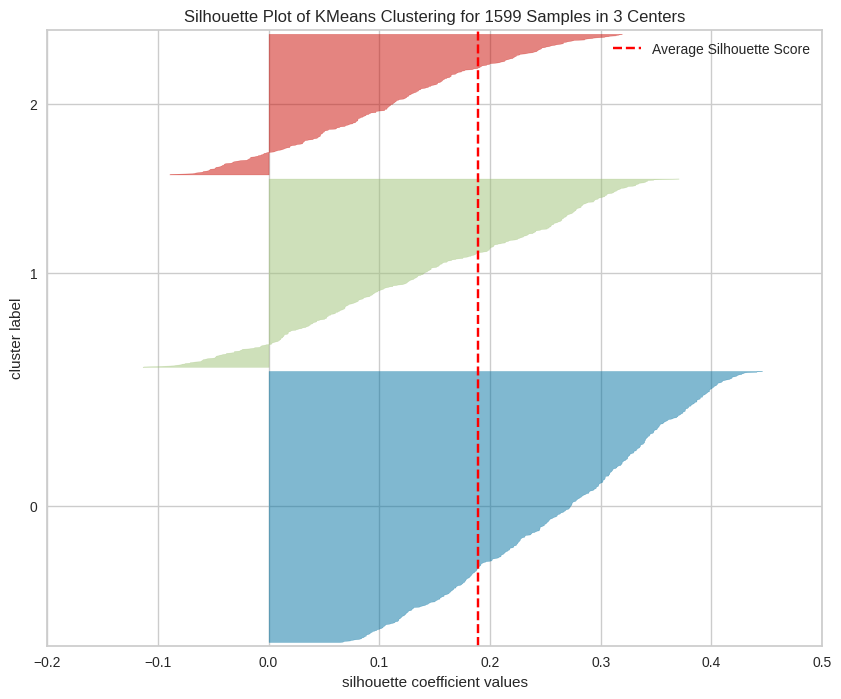

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1599 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
k = 3
kmeans_model_wine = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)

fig, ax = plt.subplots(figsize=(10, 8))
visualizer = SilhouetteVisualizer(kmeans_model_wine, colors="yellowbrick", ax=ax)
visualizer.fit(X_wine_scaled)
visualizer.show()

In [ ]:
k = 3
linkage_type = "ward"

hac_model_wine = AgglomerativeClustering(n_clusters=k, linkage=linkage_type)
hac_labels_wine = hac_model_wine.fit_predict(X_wine_scaled)

print(f"HAC Clustering with k={k}, linkage='{linkage_type}':")
print(f"  Class labels for each point (labels_):\n{hac_labels_wine}")

silhouette_avg_hac_wine = silhouette_score(X_wine_scaled, hac_labels_wine)
print(f"  Silhouette Score: {silhouette_avg_hac_wine}")

HAC Clustering with k=3, linkage='ward':
  Class labels for each point (labels_):
[1 1 1 ... 2 2 0]
  Silhouette Score: 0.15774678821183297


#### Discussion
Discuss your results and compare the algorithms you used. Which worked best? How do you know? Base your discussion on what you know about the algorithms and the hyperparameters and scoring methods. Why would you choose either algorithm?

Both methods struggled to separate the wine dataset into clear clusters, as shown by their low silhouette scores. In the selected `k=3` comparison, K-means performed better than HAC (about 0.189 versus 0.158). I would therefore choose K-means for this experiment, while noting that the comparison does not establish that it will always outperform HAC or that more clusters are better.